In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
df = pd.read_csv('loan_approval_data.csv')
df.head(10)

,Applicant_ID,Applicant_Income,Coapplicant_Income,Employment_Status,Age,Marital_Status,Dependents,Credit_Score,Existing_Loans,DTI_Ratio,Savings,Collateral_Value,Loan_Amount,Loan_Term,Loan_Purpose,Property_Area,Education_Level,Gender,Employer_Category,Loan_Approved
0,1.0,17795.0,1387.0,Salaried,51.0,Married,0.0,637.0,4.0,0.53,19403.0,45638.0,16619.0,84.0,Personal,Urban,Not Graduate,Female,Private,No
1,2.0,2860.0,2679.0,Salaried,46.0,Married,3.0,621.0,2.0,0.30,2580.0,49272.0,38687.0,NaN,Car,Semiurban,Graduate,NaN,Private,No
2,3.0,7390.0,2106.0,Salaried,25.0,Single,2.0,674.0,4.0,0.20,13844.0,6908.0,27943.0,72.0,NaN,Urban,NaN,Female,Government,Yes
3,4.0,13964.0,8173.0,Salaried,40.0,Married,2.0,579.0,3.0,0.31,9553.0,10844.0,27819.0,60.0,Business,Rural,Graduate,Female,Government,No
4,5.0,13284.0,4223.0,Self-employed,31.0,Single,2.0,721.0,1.0,0.29,9386.0,37629.0,12741.0,72.0,Car,NaN,Graduate,Male,Private,Yes
5,6.0,8265.0,4831.0,Salaried,53.0,Single,1.0,602.0,1.0,0.56,19522.0,2911.0,9798.0,36.0,Home,Semiurban,Graduate,Male,Unemployed,No
6,7.0,18850.0,2768.0,Salaried,58.0,Married,0.0,687.0,0.0,0.48,14635.0,8991.0,26143.0,24.0,Home,Rural,Graduate,Male,Private,No
7,8.0,6426.0,3186.0,Salaried,47.0,Married,2.0,636.0,4.0,NaN,671.0,11572.0,33747.0,84.0,Personal,Rural,Graduate,Female,NaN,No
8,9.0,16423.0,NaN,Salaried,54.0,Married,1.0,729.0,0.0,0.59,777.0,43066.0,34651.0,36.0,Home,Semiurban,Graduate,Male,Private,No
9,10.0,13363.0,2599.0,Contract,35.0,Single,3.0,726.0,1.0,NaN,3022.0,29693.0,22182.0,60.0,Personal,Rural,Graduate,Female,Government,Yes


In [4]:
df.info()
#hence has null values

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 20 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Applicant_ID        950 non-null    float64
 1   Applicant_Income    950 non-null    float64
 2   Coapplicant_Income  950 non-null    float64
 3   Employment_Status   950 non-null    object 
 4   Age                 950 non-null    float64
 5   Marital_Status      950 non-null    object 
 6   Dependents          950 non-null    float64
 7   Credit_Score        950 non-null    float64
 8   Existing_Loans      950 non-null    float64
 9   DTI_Ratio           950 non-null    float64
 10  Savings             950 non-null    float64
 11  Collateral_Value    950 non-null    float64
 12  Loan_Amount         950 non-null    float64
 13  Loan_Term           950 non-null    float64
 14  Loan_Purpose        950 non-null    object 
 15  Property_Area       950 non-null    object 
 16  Educati

In [5]:
df.describe()

,Applicant_ID,Applicant_Income,Coapplicant_Income,Age,Dependents,Credit_Score,Existing_Loans,DTI_Ratio,Savings,Collateral_Value,Loan_Amount,Loan_Term
count,950.000000,950.000000,950.000000,950.000000,950.000000,950.000000,950.000000,950.000000,950.000000,950.000000,950.000000,950.000000
mean,501.220000,10852.571579,5082.455789,39.971579,1.474737,676.033684,1.950526,0.347263,9940.452632,24802.792632,20522.825263,48.000000
std,289.608451,5061.632859,2943.161570,11.139797,1.105067,71.346015,1.406246,0.144341,5860.736885,14345.696031,11504.142575,24.245322
min,1.000000,2009.000000,1.000000,21.000000,0.000000,550.000000,0.000000,0.100000,65.000000,36.000000,1015.000000,12.000000
25%,250.250000,6730.750000,2472.750000,30.250000,1.000000,616.250000,1.000000,0.220000,4760.250000,12698.250000,9806.250000,24.000000
50%,499.500000,10548.000000,5205.500000,40.000000,1.000000,678.000000,2.000000,0.340000,9880.500000,24321.000000,21210.500000,48.000000
75%,752.750000,15190.000000,7620.750000,49.000000,2.000000,737.000000,3.000000,0.480000,15074.500000,36947.000000,30263.000000,72.000000
max,1000.000000,19988.000000,9996.000000,59.000000,3.000000,799.000000,4.000000,0.600000,19996.000000,49954.000000,39995.000000,84.000000


# Handle missing values

In [6]:
categorical_columns = df.select_dtypes(include = ['object']).columns
numerical_columns = df.select_dtypes(include = ['number']).columns                                     

In [7]:
categorical_columns.size + numerical_columns.size

20

In [8]:
from sklearn.impute import SimpleImputer
imp_mean = SimpleImputer(missing_values=np.nan, strategy='mean')
df[numerical_columns] = imp_mean.fit_transform(df[numerical_columns])

In [9]:
cat_mode = SimpleImputer(missing_values = np.nan, strategy = 'most_frequent')
df[categorical_columns] = cat_mode.fit_transform(df[categorical_columns])

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 20 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Applicant_ID        1000 non-null   float64
 1   Applicant_Income    1000 non-null   float64
 2   Coapplicant_Income  1000 non-null   float64
 3   Employment_Status   1000 non-null   object 
 4   Age                 1000 non-null   float64
 5   Marital_Status      1000 non-null   object 
 6   Dependents          1000 non-null   float64
 7   Credit_Score        1000 non-null   float64
 8   Existing_Loans      1000 non-null   float64
 9   DTI_Ratio           1000 non-null   float64
 10  Savings             1000 non-null   float64
 11  Collateral_Value    1000 non-null   float64
 12  Loan_Amount         1000 non-null   float64
 13  Loan_Term           1000 non-null   float64
 14  Loan_Purpose        1000 non-null   object 
 15  Property_Area       1000 non-null   object 
 16  Educati

# EDA

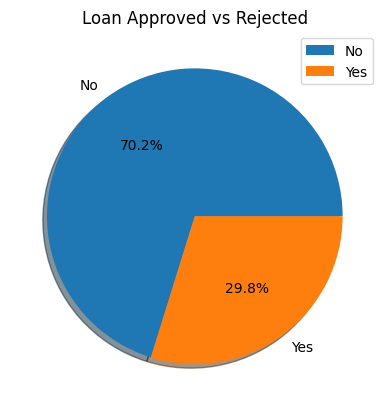

In [72]:
#how balanced are our classes

classes_count = df['Loan_Approved'].value_counts() 
plt.pie(
    classes_count, labels = ['No','Yes'], autopct = "%1.1f%%", shadow = True
)
plt.title('Loan Approved vs Rejected')
plt.legend()
plt.savefig('Loan Approved vs Rejected')
plt.show()

[Text(0, 0, '722'), Text(0, 0, '278')]

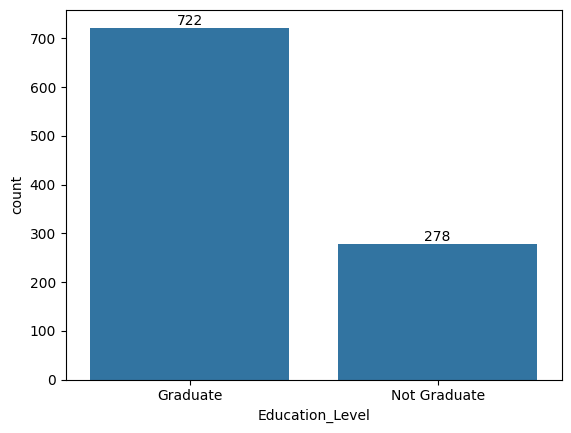

In [11]:
#categorical columns
edu_count = df['Education_Level'].value_counts()

ax =sns.barplot(edu_count)
ax.bar_label(ax.containers[0])

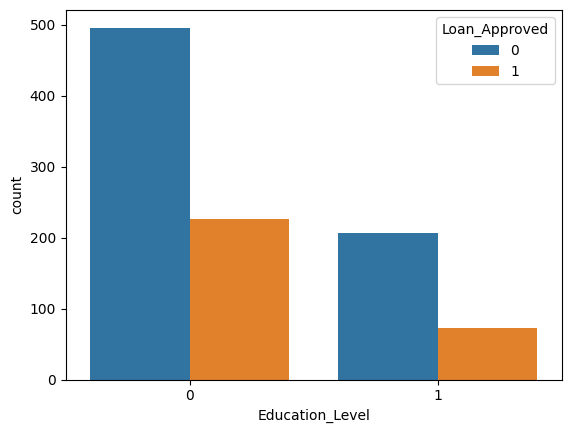

In [73]:
ax = sns.countplot(
    data = df,
    x = 'Education_Level', hue = df['Loan_Approved']
)
plt.savefig('Loan_Approved vs Education_level')

<Axes: xlabel='Applicant_Income', ylabel='Count'>

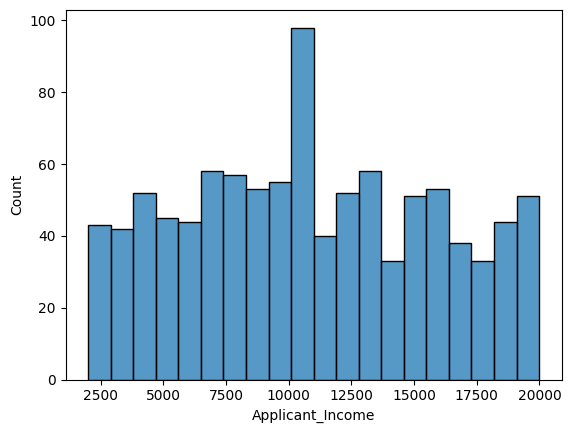

In [13]:
sns.histplot(
    data = df,
    x = 'Applicant_Income',
    bins = 20
)

<Axes: xlabel='Coapplicant_Income', ylabel='Count'>

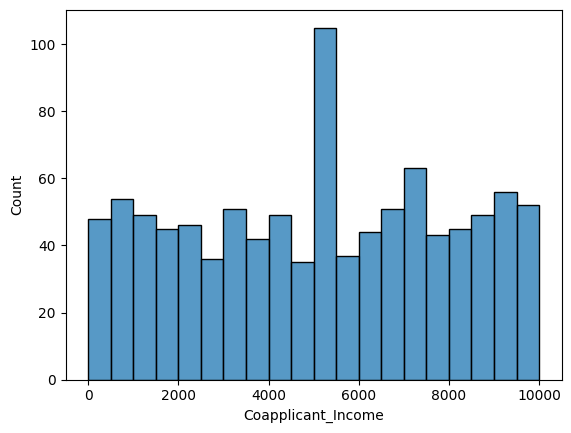

In [14]:
sns.histplot(
    data = df,
    x = 'Coapplicant_Income',
    bins = 20
)

<Axes: xlabel='Loan_Approved', ylabel='Applicant_Income'>

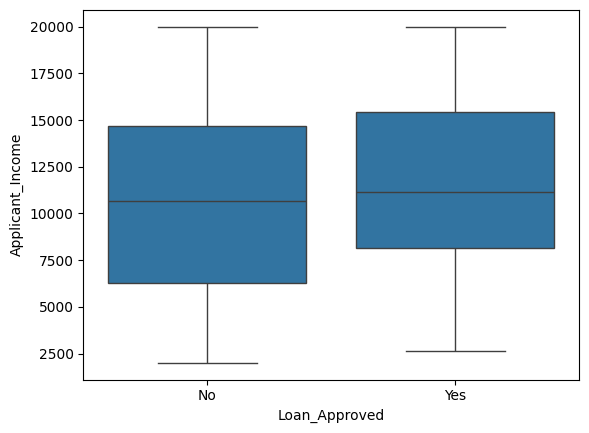

In [15]:
#check for outliers in salary
sns.boxplot(
    data = df,
    x = 'Loan_Approved',
    y = 'Applicant_Income'
)

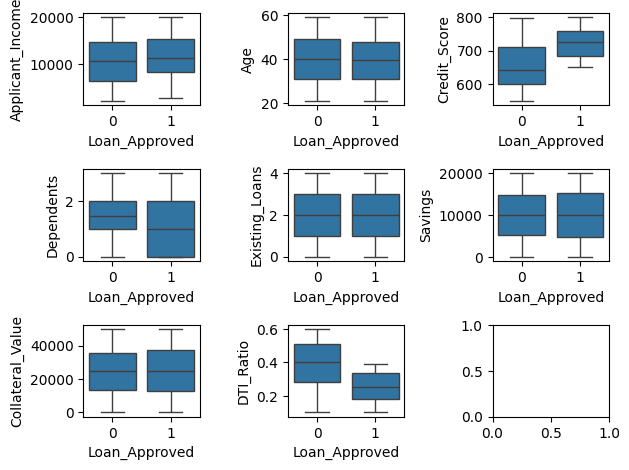

In [76]:
fig, ax = plt.subplots(3,3)

sns.boxplot(
    ax = ax[0,0],
    data = df,
    x = 'Loan_Approved',
    y = 'Applicant_Income'
)

sns.boxplot(
    ax = ax[0,1],
    data = df,
    x = 'Loan_Approved',
    y = 'Age'
)

sns.boxplot(
    ax = ax[0,2],
    data = df,
    x = 'Loan_Approved',
    y = 'Credit_Score'
)

sns.boxplot(
    ax = ax[1,0],
    data = df,
    x = 'Loan_Approved',
    y = 'Dependents'
)

sns.boxplot(
    ax = ax[1,1],
    data = df,
    x = 'Loan_Approved',
    y = 'Existing_Loans'
)

sns.boxplot(
    ax = ax[1,2],
    data = df,
    x = 'Loan_Approved',
    y = 'Savings'
)

sns.boxplot(
    ax = ax[2,0],
    data = df,
    x = 'Loan_Approved',
    y = 'Collateral_Value'
)

sns.boxplot(
    ax = ax[2,1],
    data = df,
    x = 'Loan_Approved',
    y = 'DTI_Ratio'
)
plt.tight_layout()
plt.savefig('box plots loan approved vs various categories')


<Axes: xlabel='Credit_Score', ylabel='Count'>

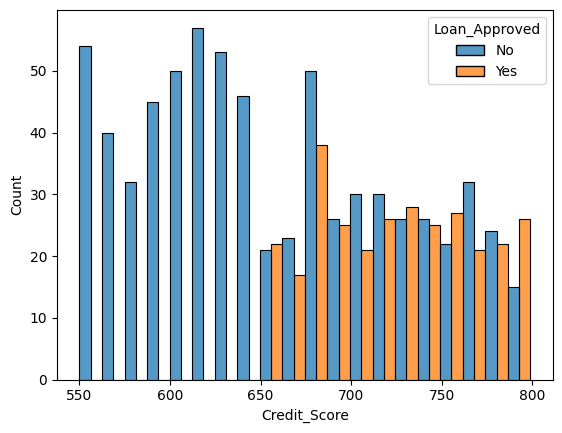

In [17]:
# histplot: approved vs credit score
sns.histplot(
    data = df,
    bins = 20,
    x = 'Credit_Score',
    hue = 'Loan_Approved',
    multiple = 'dodge'
)

<Axes: xlabel='DTI_Ratio', ylabel='Count'>

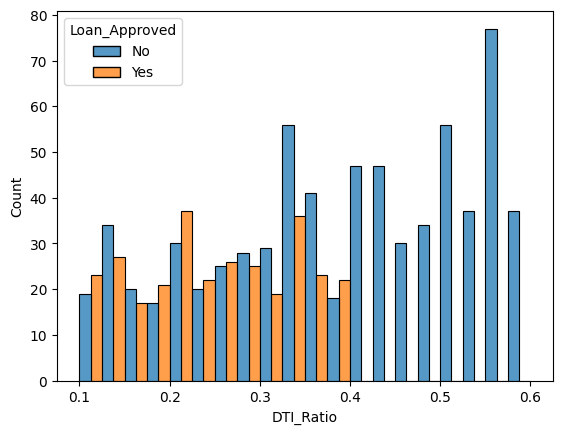

In [18]:
sns.histplot(
    data = df,
    bins = 20,
    x = 'DTI_Ratio',
    hue = 'Loan_Approved',
    multiple = 'dodge'
)

In [19]:
# drop unnecessary colums:: applicant id

df =  df.drop(columns = ['Applicant_ID'])
df.head(10)

,Applicant_Income,Coapplicant_Income,Employment_Status,Age,Marital_Status,Dependents,Credit_Score,Existing_Loans,DTI_Ratio,Savings,Collateral_Value,Loan_Amount,Loan_Term,Loan_Purpose,Property_Area,Education_Level,Gender,Employer_Category,Loan_Approved
0,17795.0,1387.000000,Salaried,51.0,Married,0.0,637.0,4.0,0.530000,19403.0,45638.0,16619.0,84.0,Personal,Urban,Not Graduate,Female,Private,No
1,2860.0,2679.000000,Salaried,46.0,Married,3.0,621.0,2.0,0.300000,2580.0,49272.0,38687.0,48.0,Car,Semiurban,Graduate,Male,Private,No
2,7390.0,2106.000000,Salaried,25.0,Single,2.0,674.0,4.0,0.200000,13844.0,6908.0,27943.0,72.0,Business,Urban,Graduate,Female,Government,Yes
3,13964.0,8173.000000,Salaried,40.0,Married,2.0,579.0,3.0,0.310000,9553.0,10844.0,27819.0,60.0,Business,Rural,Graduate,Female,Government,No
4,13284.0,4223.000000,Self-employed,31.0,Single,2.0,721.0,1.0,0.290000,9386.0,37629.0,12741.0,72.0,Car,Urban,Graduate,Male,Private,Yes
5,8265.0,4831.000000,Salaried,53.0,Single,1.0,602.0,1.0,0.560000,19522.0,2911.0,9798.0,36.0,Home,Semiurban,Graduate,Male,Unemployed,No
6,18850.0,2768.000000,Salaried,58.0,Married,0.0,687.0,0.0,0.480000,14635.0,8991.0,26143.0,24.0,Home,Rural,Graduate,Male,Private,No
7,6426.0,3186.000000,Salaried,47.0,Married,2.0,636.0,4.0,0.347263,671.0,11572.0,33747.0,84.0,Personal,Rural,Graduate,Female,Private,No
8,16423.0,5082.455789,Salaried,54.0,Married,1.0,729.0,0.0,0.590000,777.0,43066.0,34651.0,36.0,Home,Semiurban,Graduate,Male,Private,No
9,13363.0,2599.000000,Contract,35.0,Single,3.0,726.0,1.0,0.347263,3022.0,29693.0,22182.0,60.0,Personal,Rural,Graduate,Female,Government,Yes


# Feature Encoding

In [20]:
from sklearn.preprocessing import LabelEncoder, OneHotEncoder

le = LabelEncoder()
# columns = Education_Level,Loan_Approved
df['Education_Level'] = le.fit_transform(df['Education_Level'])
df['Loan_Approved'] = le.fit_transform(df['Loan_Approved'])

In [21]:
df.head(10)

,Applicant_Income,Coapplicant_Income,Employment_Status,Age,Marital_Status,Dependents,Credit_Score,Existing_Loans,DTI_Ratio,Savings,Collateral_Value,Loan_Amount,Loan_Term,Loan_Purpose,Property_Area,Education_Level,Gender,Employer_Category,Loan_Approved
0,17795.0,1387.000000,Salaried,51.0,Married,0.0,637.0,4.0,0.530000,19403.0,45638.0,16619.0,84.0,Personal,Urban,1,Female,Private,0
1,2860.0,2679.000000,Salaried,46.0,Married,3.0,621.0,2.0,0.300000,2580.0,49272.0,38687.0,48.0,Car,Semiurban,0,Male,Private,0
2,7390.0,2106.000000,Salaried,25.0,Single,2.0,674.0,4.0,0.200000,13844.0,6908.0,27943.0,72.0,Business,Urban,0,Female,Government,1
3,13964.0,8173.000000,Salaried,40.0,Married,2.0,579.0,3.0,0.310000,9553.0,10844.0,27819.0,60.0,Business,Rural,0,Female,Government,0
4,13284.0,4223.000000,Self-employed,31.0,Single,2.0,721.0,1.0,0.290000,9386.0,37629.0,12741.0,72.0,Car,Urban,0,Male,Private,1
5,8265.0,4831.000000,Salaried,53.0,Single,1.0,602.0,1.0,0.560000,19522.0,2911.0,9798.0,36.0,Home,Semiurban,0,Male,Unemployed,0
6,18850.0,2768.000000,Salaried,58.0,Married,0.0,687.0,0.0,0.480000,14635.0,8991.0,26143.0,24.0,Home,Rural,0,Male,Private,0
7,6426.0,3186.000000,Salaried,47.0,Married,2.0,636.0,4.0,0.347263,671.0,11572.0,33747.0,84.0,Personal,Rural,0,Female,Private,0
8,16423.0,5082.455789,Salaried,54.0,Married,1.0,729.0,0.0,0.590000,777.0,43066.0,34651.0,36.0,Home,Semiurban,0,Male,Private,0
9,13363.0,2599.000000,Contract,35.0,Single,3.0,726.0,1.0,0.347263,3022.0,29693.0,22182.0,60.0,Personal,Rural,0,Female,Government,1


In [22]:
#onehotencoding
cols = ['Employment_Status','Marital_Status','Loan_Purpose','Property_Area','Gender','Employer_Category']

ohe = OneHotEncoder(drop = 'first', sparse_output=False,handle_unknown = 'ignore')

encoded = ohe.fit_transform(df[cols])

encoded_df = pd.DataFrame(encoded, columns = ohe.get_feature_names_out(cols), index = df.index)

In [23]:
encoded_df.head()

,Employment_Status_Salaried,Employment_Status_Self-employed,Employment_Status_Unemployed,Marital_Status_Single,Loan_Purpose_Car,Loan_Purpose_Education,Loan_Purpose_Home,Loan_Purpose_Personal,Property_Area_Semiurban,Property_Area_Urban,Gender_Male,Employer_Category_Government,Employer_Category_MNC,Employer_Category_Private,Employer_Category_Unemployed
0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0
1,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,1.0,0.0
2,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0
3,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0
4,0.0,1.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,1.0,0.0


In [24]:
df = pd.concat([df.drop(columns = cols), encoded_df],axis = 1)
df.head(10)

,Applicant_Income,Coapplicant_Income,Age,Dependents,Credit_Score,Existing_Loans,DTI_Ratio,Savings,Collateral_Value,Loan_Amount,...,Loan_Purpose_Education,Loan_Purpose_Home,Loan_Purpose_Personal,Property_Area_Semiurban,Property_Area_Urban,Gender_Male,Employer_Category_Government,Employer_Category_MNC,Employer_Category_Private,Employer_Category_Unemployed
0,17795.0,1387.000000,51.0,0.0,637.0,4.0,0.530000,19403.0,45638.0,16619.0,...,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0
1,2860.0,2679.000000,46.0,3.0,621.0,2.0,0.300000,2580.0,49272.0,38687.0,...,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,1.0,0.0
2,7390.0,2106.000000,25.0,2.0,674.0,4.0,0.200000,13844.0,6908.0,27943.0,...,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0
3,13964.0,8173.000000,40.0,2.0,579.0,3.0,0.310000,9553.0,10844.0,27819.0,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0
4,13284.0,4223.000000,31.0,2.0,721.0,1.0,0.290000,9386.0,37629.0,12741.0,...,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,1.0,0.0
5,8265.0,4831.000000,53.0,1.0,602.0,1.0,0.560000,19522.0,2911.0,9798.0,...,0.0,1.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,1.0
6,18850.0,2768.000000,58.0,0.0,687.0,0.0,0.480000,14635.0,8991.0,26143.0,...,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0
7,6426.0,3186.000000,47.0,2.0,636.0,4.0,0.347263,671.0,11572.0,33747.0,...,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
8,16423.0,5082.455789,54.0,1.0,729.0,0.0,0.590000,777.0,43066.0,34651.0,...,0.0,1.0,0.0,1.0,0.0,1.0,0.0,0.0,1.0,0.0
9,13363.0,2599.000000,35.0,3.0,726.0,1.0,0.347263,3022.0,29693.0,22182.0,...,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0


# Correlation Heatmap

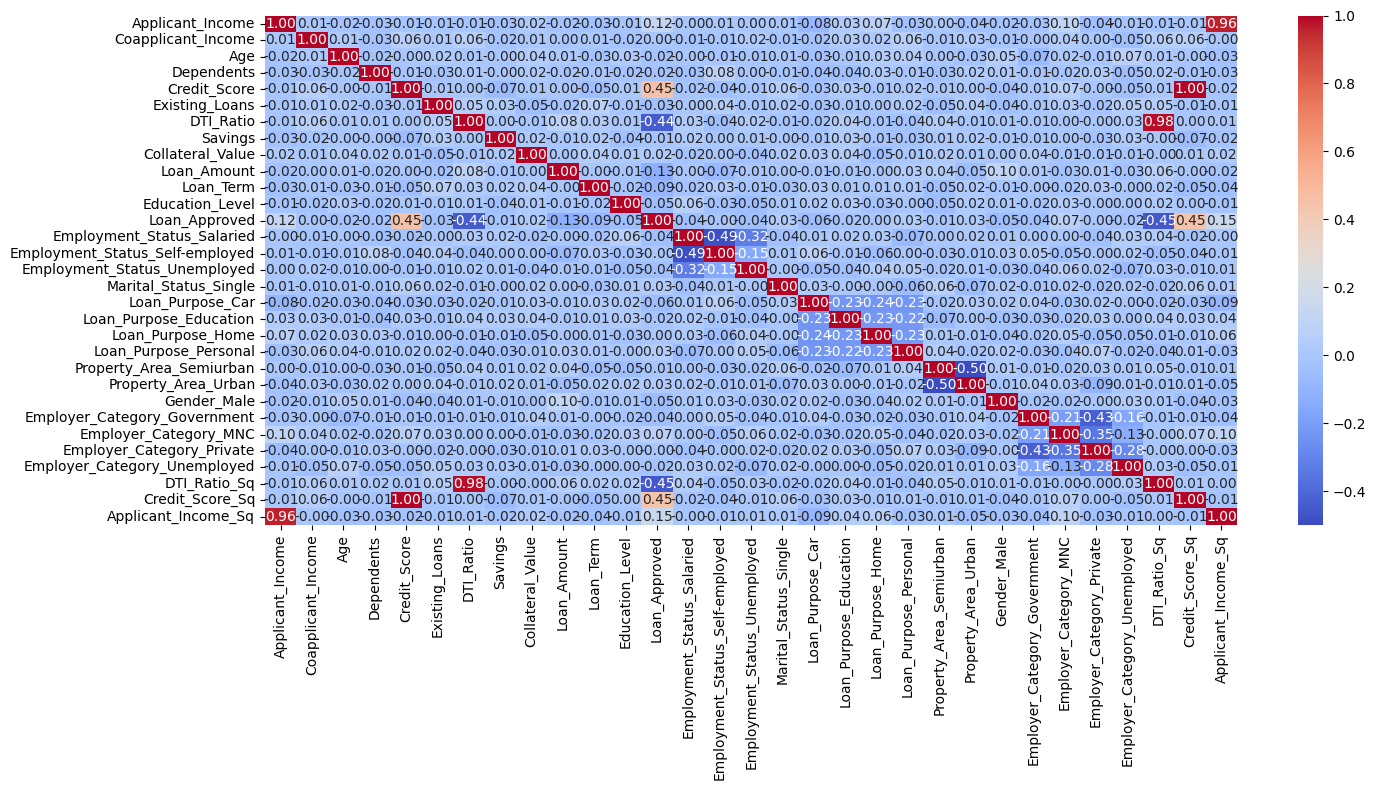

In [77]:
num_cols = df.select_dtypes(include = "number")
corr_matrix = num_cols.corr()

plt.figure(figsize = (15,8))
sns.heatmap(
    corr_matrix,
    annot = True,
    fmt = ".2f",
    cmap = "coolwarm"
)
plt.tight_layout()
plt.savefig('correlation heatmap')

# Train Test Split + Feature Scaling

In [26]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

X = df.drop('Loan_Approved', axis = 1)
y = df['Loan_Approved']

X_train,X_test, y_train, y_test = train_test_split(
    X, y, test_size = 0.2, random_state = 42
)

In [28]:
X_train.head()

,Applicant_Income,Coapplicant_Income,Age,Dependents,Credit_Score,Existing_Loans,DTI_Ratio,Savings,Collateral_Value,Loan_Amount,...,Loan_Purpose_Education,Loan_Purpose_Home,Loan_Purpose_Personal,Property_Area_Semiurban,Property_Area_Urban,Gender_Male,Employer_Category_Government,Employer_Category_MNC,Employer_Category_Private,Employer_Category_Unemployed
29,5890.000000,8041.0,31.000000,0.0,603.000000,0.000000,0.11,11906.0,8150.000000,29287.000000,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0
535,4779.000000,529.0,50.000000,0.0,614.000000,0.000000,0.21,5369.0,5430.000000,14786.000000,...,0.0,1.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0
695,10852.571579,8927.0,36.000000,0.0,584.000000,4.000000,0.22,3186.0,24802.792632,20522.825263,...,0.0,0.0,1.0,1.0,0.0,1.0,0.0,0.0,1.0,0.0
557,2384.000000,2113.0,39.971579,1.0,726.000000,4.000000,0.34,11882.0,48542.000000,13312.000000,...,0.0,1.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0
836,5228.000000,5249.0,42.000000,1.0,676.033684,1.950526,0.18,17669.0,24802.792632,13906.000000,...,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0


In [36]:
#scaling
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [38]:
X_test_scaled

array([[ 0.42610546,  0.55091079,  1.19037073, ..., -0.41388776,
         1.16316   , -0.30723158],
       [ 1.00971366,  0.58995935,  0.18392964, ..., -0.41388776,
         1.16316   , -0.30723158],
       [-0.67557096, -0.54558674,  1.09887608, ..., -0.41388776,
         1.16316   , -0.30723158],
       ...,
       [-0.67980585, -0.10106072,  1.28186537, ..., -0.41388776,
         1.16316   , -0.30723158],
       [-0.37650705, -0.97825874, -0.54802752, ..., -0.41388776,
        -0.85972695, -0.30723158],
       [-0.73647272, -1.24497436,  0.73289751, ..., -0.41388776,
         1.16316   , -0.30723158]], shape=(200, 27))

# Model Prediction

In [44]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, precision_score,recall_score,confusion_matrix,f1_score

#logistic regression
log_model = LogisticRegression()
log_model.fit(X_train_scaled, y_train)

y_pred = log_model.predict(X_test_scaled)

#evaluation metrics
print("Logistic Regression Model")
print("Precision: ", precision_score(y_test,y_pred))
print("Recall: ", recall_score(y_test,y_pred))
print("Accuracy: ", accuracy_score(y_test,y_pred))
print("F1 Score: ", f1_score(y_test,y_pred))
print("Confusion Matrix: \n", confusion_matrix(y_test,y_pred))

Logistic Regression Model
Precision:  0.7833333333333333
Recall:  0.7704918032786885
Accuracy:  0.865
F1 Score:  0.7768595041322314
Confusion Matrix: 
 [[126  13]
 [ 14  47]]


In [50]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, precision_score,recall_score,confusion_matrix,f1_score
from sklearn.model_selection import GridSearchCV

#knn 
neighbors = np.arange(1,32,2)

#gridSearchCV
classifier = KNeighborsClassifier()
param_grid = {'n_neighbors':neighbors}

classifierCV = GridSearchCV(
    classifier,
    param_grid,
    cv = 5,
    scoring = 'precision'
)

classifierCV.fit(X_train_scaled, y_train)

y_pred = classifierCV.predict(X_test_scaled)
print("best parameter: ", classifierCV.best_params_)
#evaluation metrics
print("KNN Model:\n")
print("Precision: ", precision_score(y_test,y_pred))
print("Recall: ", recall_score(y_test,y_pred))
print("Accuracy: ", accuracy_score(y_test,y_pred))
print("F1 Score: ", f1_score(y_test,y_pred))
print("Confusion Matrix: \n", confusion_matrix(y_test,y_pred))

best parameter:  {'n_neighbors': np.int64(29)}
KNN Model:

Precision:  0.8260869565217391
Recall:  0.3114754098360656
Accuracy:  0.77
F1 Score:  0.4523809523809524
Confusion Matrix: 
 [[135   4]
 [ 42  19]]


Precision has improved  a lot but simultaneously recall fell by a huge number. Hence the overall f1 score came down

In [53]:
#gaussian naive Bayes

from sklearn.naive_bayes import GaussianNB

gnb_model = GaussianNB()
gnb_model.fit(X_train_scaled,y_train)

y_pred = gnb_model.predict(X_test_scaled)

#evaluation metrics
print("Gaussian Naive Bayes Model:\n")
print("Precision: ", precision_score(y_test,y_pred))
print("Recall: ", recall_score(y_test,y_pred))
print("Accuracy: ", accuracy_score(y_test,y_pred))
print("F1 Score: ", f1_score(y_test,y_pred))
print("Confusion Matrix: \n", confusion_matrix(y_test,y_pred))

Gaussian Naive Bayes Model:

Precision:  0.8035714285714286
Recall:  0.7377049180327869
Accuracy:  0.865
F1 Score:  0.7692307692307693
Confusion Matrix: 
 [[128  11]
 [ 16  45]]


hence, by far, our best performing model is Gaussian naive bayes

# Feature Engineering

In [66]:
df['DTI_Ratio_Sq'] = df['DTI_Ratio']**2
df['Credit_Score_Sq'] = df['Credit_Score']**2

# df['Applicant_Income_Sq'] = np.log1p(df['Applicant_Income'])

X = df.drop(columns = ['DTI_Ratio','Credit_Score','Applicant_Income','Loan_Approved'])
y = df['Loan_Approved']

#train_test_split

X_train,X_test, y_train, y_test = train_test_split(
    X, y, test_size = 0.2, random_state = 42
)

In [67]:
#scaling
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [68]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, precision_score,recall_score,confusion_matrix,f1_score

#logistic regression
log_model = LogisticRegression()
log_model.fit(X_train_scaled, y_train)

y_pred = log_model.predict(X_test_scaled)

#evaluation metrics
print("Logistic Regression Model")
print("Precision: ", precision_score(y_test,y_pred))
print("Recall: ", recall_score(y_test,y_pred))
print("Accuracy: ", accuracy_score(y_test,y_pred))
print("F1 Score: ", f1_score(y_test,y_pred))
print("Confusion Matrix: \n", confusion_matrix(y_test,y_pred))

Logistic Regression Model
Precision:  0.7777777777777778
Recall:  0.8032786885245902
Accuracy:  0.87
F1 Score:  0.7903225806451613
Confusion Matrix: 
 [[125  14]
 [ 12  49]]


In [58]:
#knn 
neighbors = np.arange(1,32,2)

#gridSearchCV
classifier = KNeighborsClassifier()
param_grid = {'n_neighbors':neighbors}

classifierCV = GridSearchCV(
    classifier,
    param_grid,
    cv = 5,
    scoring = 'precision'
)

classifierCV.fit(X_train_scaled, y_train)

y_pred = classifierCV.predict(X_test_scaled)
print("best parameter: ", classifierCV.best_params_)
#evaluation metrics
print("KNN Model:\n")
print("Precision: ", precision_score(y_test,y_pred))
print("Recall: ", recall_score(y_test,y_pred))
print("Accuracy: ", accuracy_score(y_test,y_pred))
print("F1 Score: ", f1_score(y_test,y_pred))
print("Confusion Matrix: \n", confusion_matrix(y_test,y_pred))

best parameter:  {'n_neighbors': np.int64(31)}
KNN Model:

Precision:  0.8181818181818182
Recall:  0.29508196721311475
Accuracy:  0.765
F1 Score:  0.43373493975903615
Confusion Matrix: 
 [[135   4]
 [ 43  18]]


In [69]:
#gaussian naive Bayes

from sklearn.naive_bayes import GaussianNB

gnb_model = GaussianNB()
gnb_model.fit(X_train_scaled,y_train)

y_pred = gnb_model.predict(X_test_scaled)

#evaluation metrics
print("Gaussian Naive Bayes Model:\n")
print("Precision: ", precision_score(y_test,y_pred))
print("Recall: ", recall_score(y_test,y_pred))
print("Accuracy: ", accuracy_score(y_test,y_pred))
print("F1 Score: ", f1_score(y_test,y_pred))
print("Confusion Matrix: \n", confusion_matrix(y_test,y_pred))

Gaussian Naive Bayes Model:

Precision:  0.8035714285714286
Recall:  0.7377049180327869
Accuracy:  0.865
F1 Score:  0.7692307692307693
Confusion Matrix: 
 [[128  11]
 [ 16  45]]


In [71]:
models = {'logistic regression': log_model, 'knn': classifierCV, 'Gaussian Naive Bayes' : gnb_model}

for name, model in models.items():
    y_pred = model.predict(X_test_scaled)
    print(f"{name}:\n")
    print("Precision: ", precision_score(y_test,y_pred))
    print("Recall: ", recall_score(y_test,y_pred))
    print("Accuracy: ", accuracy_score(y_test,y_pred))
    print("F1 Score: ", f1_score(y_test,y_pred))
    print("Confusion Matrix: \n", confusion_matrix(y_test,y_pred),'\n')
    print("-------------------------------------------------------------------")

logistic regression:

Precision:  0.7777777777777778
Recall:  0.8032786885245902
Accuracy:  0.87
F1 Score:  0.7903225806451613
Confusion Matrix: 
 [[125  14]
 [ 12  49]] 

-------------------------------------------------------------------
knn:

Precision:  0.8181818181818182
Recall:  0.29508196721311475
Accuracy:  0.765
F1 Score:  0.43373493975903615
Confusion Matrix: 
 [[135   4]
 [ 43  18]] 

-------------------------------------------------------------------
Gaussian Naive Bayes:

Precision:  0.8035714285714286
Recall:  0.7377049180327869
Accuracy:  0.865
F1 Score:  0.7692307692307693
Confusion Matrix: 
 [[128  11]
 [ 16  45]] 

-------------------------------------------------------------------
